In [1]:
# PACKAGES

import random, time, pickle
from datetime import datetime
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx
from model import *

In [2]:
# FIGURE SETTINGS

alphabet = ['(' + _ +')' for _ in 'abcdefghijklmnopqrstuvwxyz']
blues = [plt.cm.PuBu(1-val) for val in [0.0, 0.25, 0.50, 0.75]]

plt.rcParams["font.family"] = "Arial"
plt.rcParams['mathtext.fontset'] = "custom"
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [3]:
# SET CONFIGURATIONS

# Set social graph
n = 4
complete_graph=True

# Set simulation time and resolution
tmax = 3000
time_step=0.01

# Set model parameters
threshold_x = 0.5

# Set seeds
seeds = [0,1,2]
# seed 0: two slow adopters, but eventually all
# seed 1: one action taker only
# seed 2: no actions taken   

In [4]:
# PROCESS CONFIGURATIONS

# Create adjacency matrix
if complete_graph:
    A = np.ones((n,n))-np.eye(n) 
else:
    A = np.random.choice([1, 0], size=(n, n)) 
    A = A - np.diag(np.diag(A))

In [5]:
# LOAD OR GENERATE AND SAVE DATA

load = True
file_loc = 'data/data-for-figure-2.p'

if load:
    t, x, y, a = pickle.load(open(file_loc, 'rb'))

else:
    # INITIALIZE DATA LISTS
    t, x, y, a = list(range(3)), list(range(3)), list(range(3)), list(range(3))

    # GENERATE DATA
    for si, s in enumerate(seeds):
        np.random.seed(s) 

        # Generate random internal attitudes
        alphas = np.sort(np.random.uniform(low=-0.4, high=1, size=n))[::-1]

        # make system
        system = make_system(A, alphas, shiftS=-0.5, shiftC=0.5, scaleC=0.05,
            growth='symlogistic', threshold_x=threshold_x, 
            immediacy_parameter=0.02)

        # INTEGRATE
        t[si], x[si], y[si] = integrate_system(system, t_max=tmax, 
            time_step=time_step, max_events=1E4)
        a[si] = np.copy(alphas)
        
    # SAVE DATA
    pickle.dump([t, x, y, a], open(file_loc, 'wb'))

FileNotFoundError: [Errno 2] No such file or directory: 'data/data-for-figure-2.p'

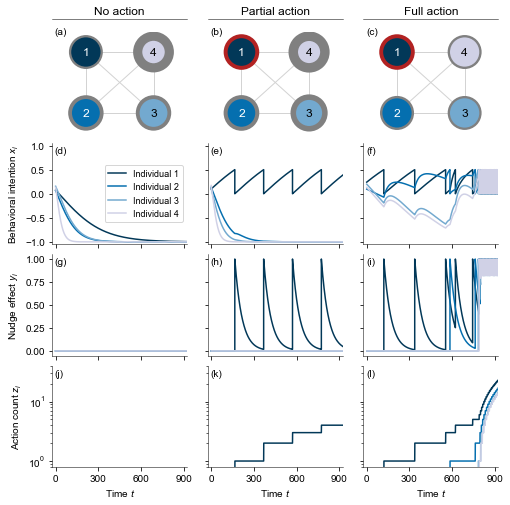

In [ ]:
# PLOT FIGURE

lw = lambda num: 2+np.abs(0.5-(0.4+num)/1.6)*15
xticks = [0,300,600,900]

plt.figure(figsize=(8,8))

for j in range(3):
    
    # reverse order of panels
    s = [2,1,0][j]
    
    # add column titles
    ax0 = plt.subplot(4,3,1+j)
    if j==0:
        plt.title("No action\n", fontsize=12)
    if j==1:
        plt.title("Partial action\n", fontsize=12)
    if j==2:
        plt.title("Full action\n", fontsize=12)
    ax0.text(0.02, 0.98, alphabet[j], transform=ax0.transAxes)

    # underline titles
    dx, dy = 0.5, 0.33
    ax0.set_xlim([-0-dx,1+dx])
    ax0.set_ylim([-0-dy,1+dy])
    trans = ax0.get_xaxis_transform()
    ax0.plot([-.5,1.5], [1.125,1.125], color='black', lw=0.5, transform=trans,
        clip_on=False)

    # add networks
    G = nx.complete_graph(4)
    pos = [[0,1],[0,0],[1,0],[1,1]]
    nx.draw_networkx_nodes(G, pos, node_size=1000, node_color=blues, 
        linewidths=[lw(_) for _ in a[s]], 
        edgecolors=[('gray' if _<0.5 else 'firebrick') for _ in a[s]])
    nx.draw_networkx_edges(G, pos, edge_color='lightgray')
    nx.draw_networkx_labels(G, pos, labels={_: str(_+1) for _ in range(2)}, 
        font_color='white', font_family='Arial')
    nx.draw_networkx_labels(G, pos, labels={_: str(_+1) for _ in range(2,4)}, 
        font_color='black', font_family='Arial')
    ax0.axis('off')
    
    # plot simulation results
    ax1 = plt.subplot(4,3,4+j)
    ax1.text(0.02, 0.9, alphabet[3+j], transform=ax1.transAxes)
    for i in range(n):
        plt.plot(t[s], x[s][i], color=blues[i], ls='-', label='Individual '+str(i+1))
    plt.ylim([-1.05,1.05])
    plt.xlim([-25,925])

    plt.xlabel('')
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([])
    if j==0:
        plt.ylabel(r'Behavioral intention $x_i$')
        plt.legend(loc=7, fontsize=9)
    else:
        ax1.set_yticklabels([])

    ax2 = plt.subplot(4,3,7+j) 
    ax2.text(0.02, 0.9, alphabet[6+j], transform=ax2.transAxes)
    for i in range(n):
        plt.plot(t[s], x[s][n+i], color=blues[i], ls='-', label=str(i))
    plt.ylim([-0.05,1.05])
    plt.xlim([-25,925])

    plt.xlabel('')
    ax2.set_xticks(xticks)
    ax2.set_xticklabels([])
    if j==0:
        plt.ylabel(r'Nudge effect $y_i$')
    else:
        ax2.set_yticklabels([])

    ax3 = plt.subplot(4,3,10+j)
    ax3.text(0.02, 0.9, alphabet[9+j], transform=ax3.transAxes)
    for i in range(n):
        plt.semilogy(t[s], y[s][i], color=blues[i], ls='-', label=str(i))
    plt.ylim([0.8,40])
    plt.xlim([-25,925])

    plt.xlabel(r'Time $t$')
    ax3.set_xticks(xticks)
    if j==0:
        plt.ylabel(r'Action count $z_i$')
    else:
        ax3.set_yticklabels([])

plt.subplots_adjust(hspace=0.1, wspace=0.15)

# Get the current date-time string
current_datetime = datetime.now()
dts = current_datetime.strftime("%Y-%m-%d_%H.%M.%S")

# save figure with current date and time
plt.savefig('figures/figure-2_'+dts+'.pdf')